# Analisando investimentos

In [35]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import math

In [36]:
# Lendo o arquivo
caminho = 'Arquivo_Barsi.xlsx'
file = pd.ExcelFile(caminho)
abas = file.sheet_names
abas

['Bolsa Barsi', 'valor_investido_vs_investimento', 'Compras']

In [37]:
contador = 0 
while contador < 3:
    for guia in abas:
        if contador == 0:
            df_precos = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        elif contador ==1:
            df_valor_investido_investimento = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        else:
            df_valor_compras = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
    

In [38]:
df_precos

,Date,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
0,2000-01-31,0.000000,0.000000,0.000000,0.000000,0.00,15.541043,0.000000,0.465056,0.000000,0.000000
1,2000-02-29,0.000000,0.000000,0.000000,0.000000,0.00,13.490949,0.000000,0.438566,0.000000,0.000000
2,2000-03-31,0.000000,0.000000,0.000000,0.000000,0.00,13.623214,0.000000,0.370279,0.000000,0.000000
3,2000-04-30,0.000000,0.000000,0.000000,0.000000,0.00,13.226420,0.000000,0.353207,0.000000,0.000000
4,2000-05-31,0.000000,0.000000,0.000000,0.000000,0.00,12.234439,0.000000,0.329660,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31,22.477026,11.544510,3.514680,4.456480,16.00,98.500000,11.676416,27.222099,22.286385,73.612267
296,2024-09-30,22.134035,11.181598,3.514680,4.383123,16.50,91.099998,10.862386,26.484249,20.886896,79.634514
297,2024-10-31,22.143641,11.367958,3.802602,4.418293,16.40,91.330002,10.561957,25.656006,20.052954,74.145416
298,2024-11-30,24.382023,11.320000,3.830980,4.360662,16.15,84.699997,10.214587,24.597614,19.391552,78.591690


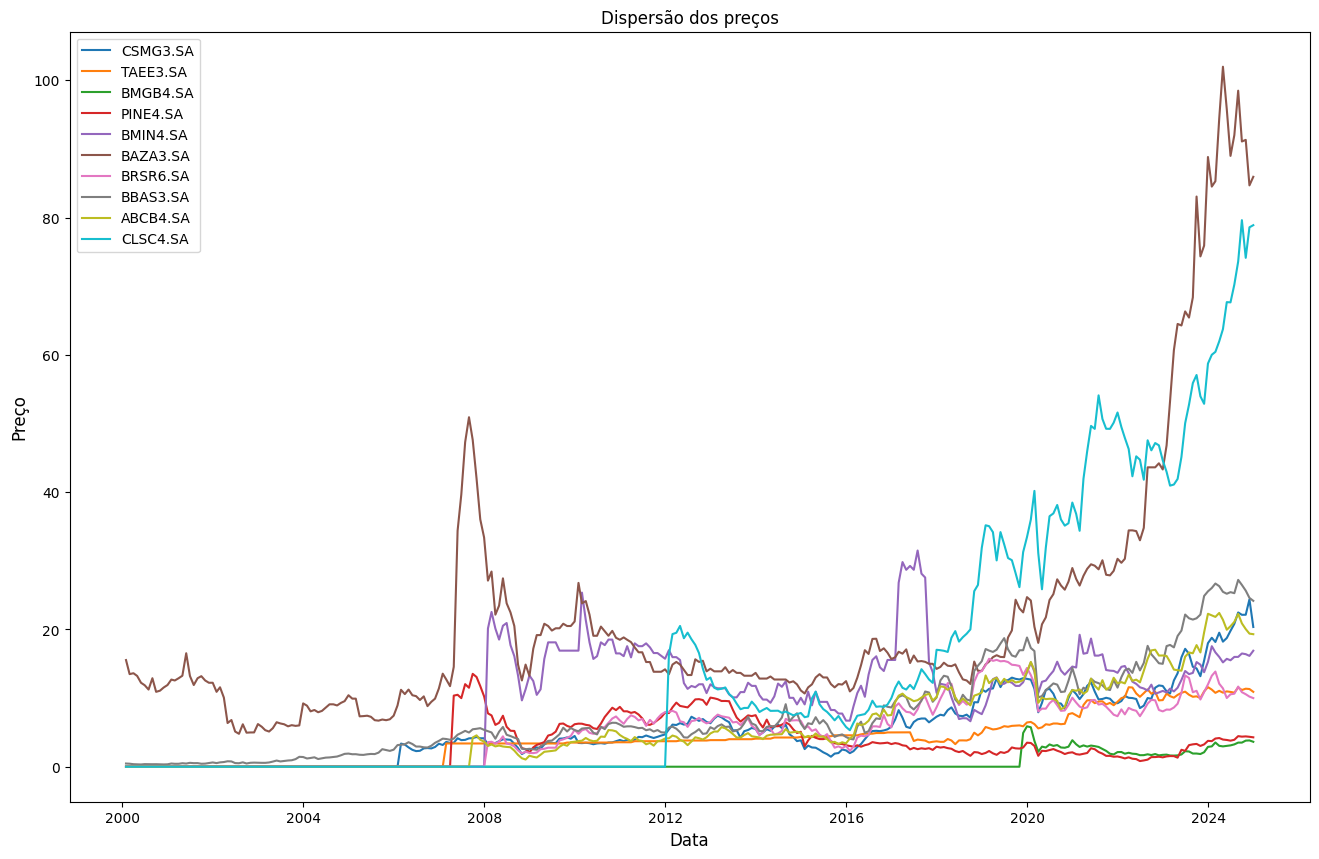

In [39]:
df_precos['Date'] = pd.to_datetime(df_precos['Date'])

plt.figure(figsize=(16,10))
# Para plotar n precisa criar dicionario ou algo do gerando o proprio plt vai implementando
for coluna in df_precos.columns[1:]:
    plt.plot(df_precos['Date'], df_precos[coluna], label=coluna)
plt.title('Dispersão dos preços', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço', fontsize=12)
plt.legend(loc='upper left', fontsize=10) 
plt.show()

# oq eu preciso fazer
 - Preciso dos desvios padrões dos ativos
 - retono dos ativos
 - Preciso da correlação entre os ativos, descorbrir um jeito de calcular
 - preciso pegar o valor da ultima linha do preco de cada ativo para calcular o valor da carteira
- Com o valor carteira determinar o percentual de cada ativo na carteira e calcular o retorno esperado
- Depois calcular o risco do portifolio defir uma função que faça isso
- retorno esperado
Calcular o indice sharp , utilizando inflação e selic media
- Calcular a renda anual que a carteira teria
Calcular o ganho de capital
retorno levar em consideração o retorno logaritimo pegar no livro do assaf neto depois (TCC escrito)


In [40]:
array = np.array([df_precos[acao].values for acao in df_precos.columns[1:]])
df_precos.set_index('Date', inplace=True)

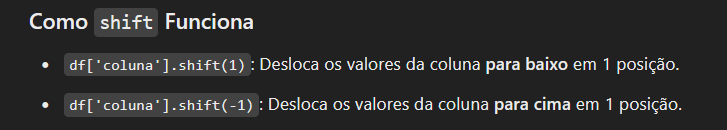

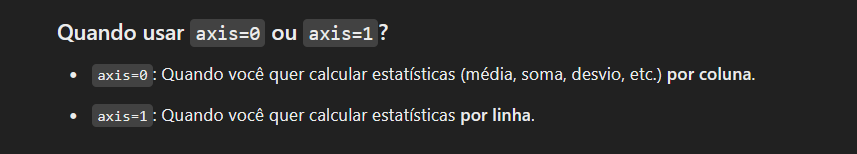

In [41]:
desvio_padro = np.std(array, axis=1)
desvio_padro

array([ 5.16483463,  3.3989675 ,  1.17442697,  3.1767244 ,  7.54865914,
       19.40313894,  4.4740542 ,  6.59126909,  5.92496526, 19.93101758])

In [42]:
# Ver quantos meses cada acao ficou em negociação para, para definir o retorno anual
dict_ano_negociado = {}
for acao in df_valor_compras['Acao']:
    dict_ano_negociado[acao]= (df_precos[df_precos[acao]!=0][acao].count())/12
dict_ano_negociado

{'CSMG3.SA': np.float64(18.916666666666668),
 'TAEE3.SA': np.float64(17.916666666666668),
 'BMGB4.SA': np.float64(5.166666666666667),
 'PINE4.SA': np.float64(17.75),
 'BMIN4.SA': np.float64(17.0),
 'BAZA3.SA': np.float64(25.0),
 'BRSR6.SA': np.float64(17.0),
 'BBAS3.SA': np.float64(25.0),
 'ABCB4.SA': np.float64(17.333333333333332),
 'CLSC4.SA': np.float64(13.0)}

In [43]:
dict_retornos = {}
for acao in df_valor_compras['Acao']:
    retorno_logaritimo_soma = np.log(df_precos[acao].replace(0,np.nan)/df_precos[acao].replace(0,np.nan).shift(1)).sum()
    vezes_multi_capital = np.exp(retorno_logaritimo_soma)-1
    retorno_anual = (1+vezes_multi_capital)**(1/dict_ano_negociado[acao])-1
    dict_retornos[acao]= retorno_anual*100
dict_retornos

{'CSMG3.SA': np.float64(9.969895279811958),
 'TAEE3.SA': np.float64(6.744358004987627),
 'BMGB4.SA': np.float64(-5.696991085065994),
 'PINE4.SA': np.float64(-4.853502068077464),
 'BMIN4.SA': np.float64(-1.024676522497403),
 'BAZA3.SA': np.float64(7.080558538446047),
 'BRSR6.SA': np.float64(6.218765245114866),
 'BBAS3.SA': np.float64(17.119942460220415),
 'ABCB4.SA': np.float64(9.11318043582925),
 'CLSC4.SA': np.float64(12.905080008678915)}

In [44]:
# Calcular correlações
df_corre = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].replace(0,np.nan)
df_corre

,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
Date,,,,,,,,,,
2000-01-31,NaN,NaN,NaN,NaN,NaN,15.541043,NaN,0.465056,NaN,NaN
2000-02-29,NaN,NaN,NaN,NaN,NaN,13.490949,NaN,0.438566,NaN,NaN
2000-03-31,NaN,NaN,NaN,NaN,NaN,13.623214,NaN,0.370279,NaN,NaN
2000-04-30,NaN,NaN,NaN,NaN,NaN,13.226420,NaN,0.353207,NaN,NaN
2000-05-31,NaN,NaN,NaN,NaN,NaN,12.234439,NaN,0.329660,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-08-31,22.477026,11.544510,3.514680,4.456480,16.00,98.500000,11.676416,27.222099,22.286385,73.612267
2024-09-30,22.134035,11.181598,3.514680,4.383123,16.50,91.099998,10.862386,26.484249,20.886896,79.634514
2024-10-31,22.143641,11.367958,3.802602,4.418293,16.40,91.330002,10.561957,25.656006,20.052954,74.145416


In [45]:
correlacao = df_corre.corr()
correlacao

,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
CSMG3.SA,1.000000,0.829518,0.342447,-0.389452,0.026630,0.797776,0.769658,0.954022,0.929141,0.911760
TAEE3.SA,0.829518,1.000000,-0.404283,-0.533411,-0.029003,0.776264,0.506497,0.848276,0.870722,0.913421
BMGB4.SA,0.342447,-0.404283,1.000000,0.612144,0.481920,0.010608,0.609133,0.194603,0.098706,0.064409
PINE4.SA,-0.389452,-0.533411,0.612144,1.000000,0.116953,-0.131351,-0.362868,-0.495317,-0.543175,-0.394740
BMIN4.SA,0.026630,-0.029003,0.481920,0.116953,1.000000,0.133485,-0.017411,0.006561,0.038329,0.188823
BAZA3.SA,0.797776,0.776264,0.010608,-0.131351,0.133485,1.000000,0.396848,0.816162,0.778984,0.859299
BRSR6.SA,0.769658,0.506497,0.609133,-0.362868,-0.017411,0.396848,1.000000,0.797178,0.772763,0.569842
BBAS3.SA,0.954022,0.848276,0.194603,-0.495317,0.006561,0.816162,0.797178,1.000000,0.970580,0.881903
ABCB4.SA,0.929141,0.870722,0.098706,-0.543175,0.038329,0.778984,0.772763,0.970580,1.000000,0.891082
CLSC4.SA,0.911760,0.913421,0.064409,-0.394740,0.188823,0.859299,0.569842,0.881903,0.891082,1.000000


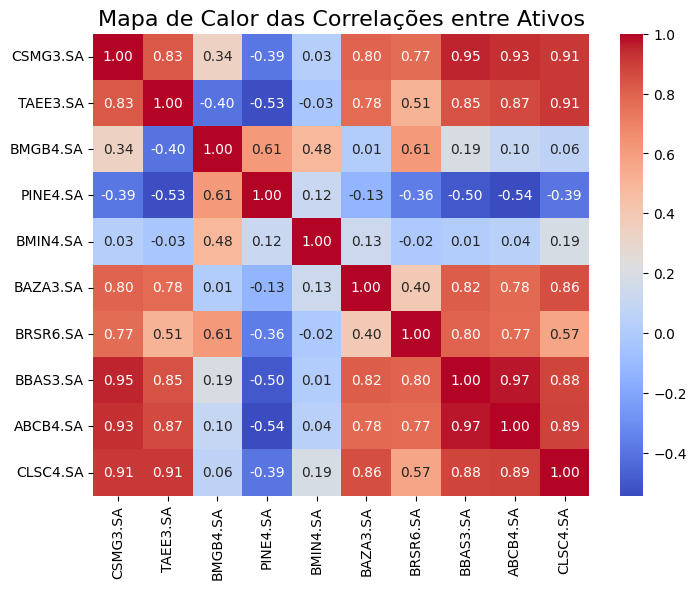

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

# Personalizando o gráfico
plt.title('Mapa de Calor das Correlações entre Ativos', fontsize=16)
plt.show()

In [47]:
desvio_padro

array([ 5.16483463,  3.3989675 ,  1.17442697,  3.1767244 ,  7.54865914,
       19.40313894,  4.4740542 ,  6.59126909,  5.92496526, 19.93101758])

In [48]:
dict_desvio = {acao:0 for acao in df_valor_compras['Acao']}
contador = 0
for acao in df_valor_compras['Acao']:
    dict_desvio[acao]= desvio_padro[contador]
    contador +=1
dict_desvio

{'CSMG3.SA': np.float64(5.164834629062458),
 'TAEE3.SA': np.float64(3.3989674960605565),
 'BMGB4.SA': np.float64(1.1744269717890874),
 'PINE4.SA': np.float64(3.176724398588895),
 'BMIN4.SA': np.float64(7.548659137987534),
 'BAZA3.SA': np.float64(19.403138937368066),
 'BRSR6.SA': np.float64(4.474054196825199),
 'BBAS3.SA': np.float64(6.591269092505504),
 'ABCB4.SA': np.float64(5.9249652553168906),
 'CLSC4.SA': np.float64(19.931017578813567)}

In [49]:
df_precos_final = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].tail(1)
df_precos_final

,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
Date,,,,,,,,,,
2024-12-31,20.358307,10.91,3.633368,4.283823,16.9,85.949997,9.999047,24.17,19.309999,78.904716


In [50]:
dict_valor_ativo = {}
contador = 0
while contador < len(df_valor_compras):
    acao = qtd=df_valor_compras.loc[contador,'Acao']
    qtd=df_valor_compras.loc[contador,'Qtd_comprada']
    dict_valor_ativo[acao]=qtd
    contador += 1
dict_valor_ativo
        

{'CSMG3.SA': np.int64(367),
 'TAEE3.SA': np.int64(305),
 'BMGB4.SA': np.int64(119),
 'PINE4.SA': np.int64(126),
 'BMIN4.SA': np.int64(133),
 'BAZA3.SA': np.int64(307),
 'BRSR6.SA': np.int64(158),
 'BBAS3.SA': np.int64(728),
 'ABCB4.SA': np.int64(147),
 'CLSC4.SA': np.int64(41)}

In [51]:
valor_total = 0
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    valor_total += preco*qtd
print(valor_total)


[65654.802881]


In [52]:
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    porcentagem_ativo[acao]= (preco*qtd)/valor_total
porcentagem_ativo

{'CSMG3.SA': array([0.11379973]),
 'TAEE3.SA': array([0.05068251]),
 'BMGB4.SA': array([0.00658552]),
 'PINE4.SA': array([0.00822121]),
 'BMIN4.SA': array([0.03423512]),
 'BAZA3.SA': array([0.40189975]),
 'BRSR6.SA': array([0.02406297]),
 'BBAS3.SA': array([0.26800416]),
 'ABCB4.SA': array([0.04323476]),
 'CLSC4.SA': array([0.04927428])}

In [53]:
def variancia_risco_port(participacao_1,participacao_2,delta_1,delta_2,corr_1_2):
    variancia = participacao_1*participacao_2*delta_1*delta_2*corr_1_2
    return variancia

In [54]:
correlacao

,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
CSMG3.SA,1.000000,0.829518,0.342447,-0.389452,0.026630,0.797776,0.769658,0.954022,0.929141,0.911760
TAEE3.SA,0.829518,1.000000,-0.404283,-0.533411,-0.029003,0.776264,0.506497,0.848276,0.870722,0.913421
BMGB4.SA,0.342447,-0.404283,1.000000,0.612144,0.481920,0.010608,0.609133,0.194603,0.098706,0.064409
PINE4.SA,-0.389452,-0.533411,0.612144,1.000000,0.116953,-0.131351,-0.362868,-0.495317,-0.543175,-0.394740
BMIN4.SA,0.026630,-0.029003,0.481920,0.116953,1.000000,0.133485,-0.017411,0.006561,0.038329,0.188823
BAZA3.SA,0.797776,0.776264,0.010608,-0.131351,0.133485,1.000000,0.396848,0.816162,0.778984,0.859299
BRSR6.SA,0.769658,0.506497,0.609133,-0.362868,-0.017411,0.396848,1.000000,0.797178,0.772763,0.569842
BBAS3.SA,0.954022,0.848276,0.194603,-0.495317,0.006561,0.816162,0.797178,1.000000,0.970580,0.881903
ABCB4.SA,0.929141,0.870722,0.098706,-0.543175,0.038329,0.778984,0.772763,0.970580,1.000000,0.891082
CLSC4.SA,0.911760,0.913421,0.064409,-0.394740,0.188823,0.859299,0.569842,0.881903,0.891082,1.000000


In [55]:
variacia_port = 0
for acao_1 in df_valor_compras['Acao']:
    for acao_2 in df_valor_compras['Acao']:
        participacao_1 = porcentagem_ativo[acao_1]
        participacao_2 = porcentagem_ativo[acao_2]
        desv_padro_1 = dict_desvio[acao_1]
        desv_padro_2 = dict_desvio[acao_2]
        corre = correlacao.loc[acao_1,acao_2]
        variacia_port +=variancia_risco_port(participacao_1,participacao_2,desv_padro_1,desv_padro_2,corre)
desv_pad_port=variacia_port**(1/2)
desv_pad_port

array([11.14054114])

# Quando se junta 2 arrays em um terceiro eles apenas pegam cada array e transforma numa dimensaõ de um terceiro, para juntar 2 arrays em 1 só é necessario concatenar
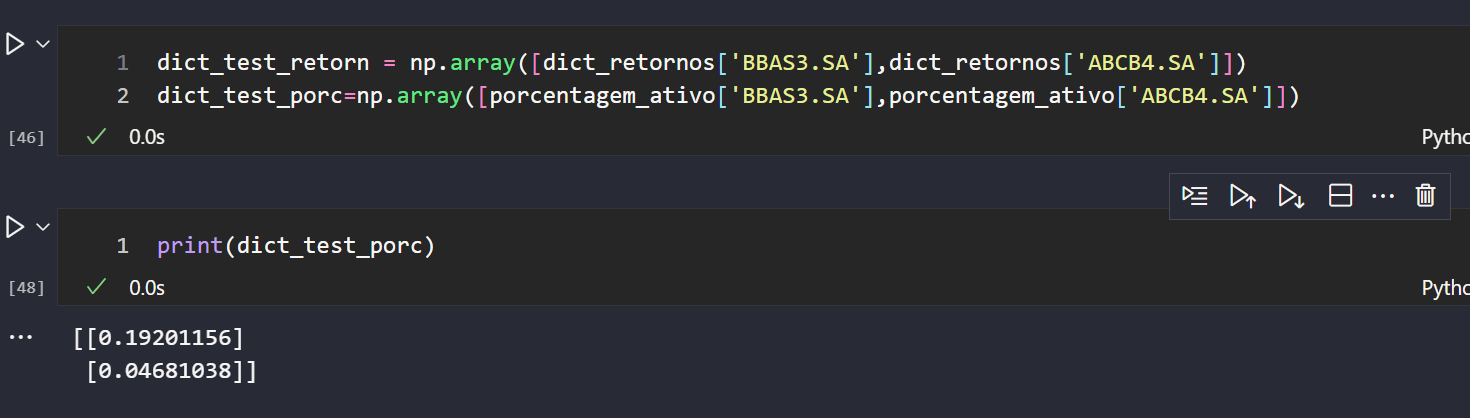

In [56]:
retornos = np.array([dict_retornos[acao] for acao in dict_retornos.keys()])
porcentagens=np.concatenate([porcentagem_ativo[acao] for acao in porcentagem_ativo.keys()])

In [57]:
print(retornos,porcentagens)

[ 9.96989528  6.744358   -5.69699109 -4.85350207 -1.02467652  7.08055854
  6.21876525 17.11994246  9.11318044 12.90508001] [0.11379973 0.05068251 0.00658552 0.00822121 0.03423512 0.40189975
 0.02406297 0.26800416 0.04323476 0.04927428]


In [58]:
retorno_esperado = sum(retornos*porcentagens)
retorno_esperado

np.float64(9.977320329193002)

In [59]:
df_valor_investido_investimento

,Nome,Valor
0,carteira_contabil_barsi,14969.804311
1,valor_investido_barsi,14973.120000


In [60]:
Total_capital_faltou_investir = df_valor_investido_investimento.loc[1,'Valor',] - df_valor_investido_investimento.loc[0,'Valor',] 
Total_capital_faltou_investir

np.float64(3.3156886351207504)

In [61]:
ganho_capital = valor_total - df_valor_investido_investimento.loc[1,'Valor',]
ganho_capital

array([50681.682881])

In [62]:
contador = 0
valor_recebido_total=0
while contador < len(df_valor_compras):
    for acao in df_valor_compras['Acao']:
        empresa = yf.Ticker(acao)
        dividendos = empresa.dividends
        if not dividendos.empty:
            dividendos_anuais_geral = dividendos.groupby(dividendos.index.year).sum()
            dividendo_ultimo_ano = dividendos_anuais_geral.tail(1)
            valor_pago = df_valor_compras.loc[contador, 'Qtd_comprada'] * dividendo_ultimo_ano.values
            valor_recebido_total+= valor_pago
            print(dividendo_ultimo_ano,valor_pago)
        else:
            valor_pago = 0  
        contador +=1
valor_recebido_total
        

Date
2025    0.511667
Name: Dividends, dtype: float64 [187.781789]
Date
2024    1.177485
Name: Dividends, dtype: float64 [359.132925]
Date
2025    0.1
Name: Dividends, dtype: float64 [11.9]
Date
2025    0.176661
Name: Dividends, dtype: float64 [22.259286]
Date
2024    1.4
Name: Dividends, dtype: float64 [186.2]
Date
2024    6.625162
Name: Dividends, dtype: float64 [2033.924734]
Date
2025    0.220063
Name: Dividends, dtype: float64 [34.769954]
Date
2024    2.188257
Name: Dividends, dtype: float64 [1593.051096]
Date
2024    2.386
Name: Dividends, dtype: float64 [350.742]
Date
2025    1.618074
Name: Dividends, dtype: float64 [66.341034]


array([4846.102818])

In [63]:
SELIC_MEDIA = 12.15999870500932
DESV_PAD_SELIC = 4.793701588763131
INFLACAO = 6.18

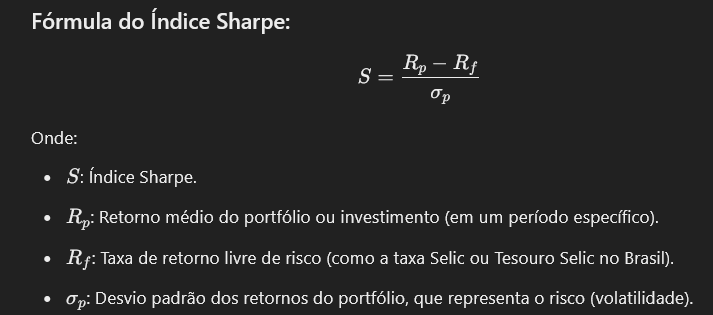

In [64]:
indice_sharpe_inflação = (retorno_esperado - INFLACAO)/desv_pad_port
indice_sharpe_inflação

print(f'Oferece um retorono de {indice_sharpe_inflação} para cada unidade de risco assumido')

Oferece um retorono de [0.340856] para cada unidade de risco assumido


In [65]:
# Para taxa que sofre grandes variações pode se considerar o desvio padrao desse retorno no indice sharpe
# Devido a cenario de economia emergente e longo prazo gera essa variação

indice_sharpe_selic = (retorno_esperado-SELIC_MEDIA)/desv_pad_port[0]
indice_sharpe_selic
print(f'Oferece um retorono de {indice_sharpe_selic} para cada unidade de risco assumido')

Oferece um retorono de -0.1959221144694144 para cada unidade de risco assumido


In [66]:
class Analise_investimento:
    def __init__(self,preco):
        self.preco = preco
    
    def desvio_pad(self):
        array = np.array([self.preco[acao].values for acao in self.preco.columns[1:]])
        desvio_pad=np.std(array, axis=1)
        return desvio_pad

In [67]:
dados = {'risco_portifolio':desv_pad_port, 'Retorno_portifolio':retorno_esperado,
         'Indice_sharpe_inflacao':indice_sharpe_inflação,
         'indice_sharpe_selic':indice_sharpe_selic,'Dividendos':valor_recebido_total
         ,'ganho_capital':ganho_capital}
dados_df=pd.DataFrame(dados)

In [68]:
with pd.ExcelWriter('base_analise_barsi.xlsx',engine='openpyxl') as writer:
        dados_df.to_excel(writer,sheet_name='Analise', index=False)
